# Changepoint detection with correlated samples using Metropolis Hastings

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

## Autocorrelated signal with no changepoints

A first order autoregressive function for a function $x$ with $N$ samples is given by

$$
x_i = \phi x_{i-1} + \epsilon
$$

where $x_i$ is the sample at time index $i$, $x_{i-1}$ is the sample at time index $i-1$, $\phi \in [-1,1]$ is the autoregression coefficient and $\epsilon$ is normally distributed noise where $\epsilon \sim N(0, \sigma)$.

The sample at index $i$ can be written as

$$
x_i \sim N( \phi x_{i-1}, \sigma).
$$

The probability of the samples $x$ given the autoregression coefficient and noise is given by

$$
p(x | \phi, \sigma) = p(x_0) \sum_{i=1}^{N-1} p(x_i | x_{i-1}, \phi, \sigma).
$$

From Bayes' theorem

$$
p(\phi, \sigma | x) = \frac{p(x, \phi, \sigma)}{p(x)}
$$

where the joint probability is given by

$$
p(x, \phi, \sigma) = p(x | \phi, \sigma) p(\phi) p(\sigma)
$$

and $p(\phi)$ is the prior probability of $\phi$ and $p(\sigma)$ is the prior probability of $\sigma$. 

The log of the joint probability is given by

$$
\begin{align*}
\ln p(x, \phi, \sigma) &= \ln p(x | \phi, \sigma) + \ln p(\phi) + \ln p(\sigma) \\
    &= \ln p(x_0) + \sum_{i=1}^{N-1} p(x_i | x_{i-1}, \phi, \sigma) + \ln p(\phi) + \ln p(\sigma).
\end{align*}
$$

Inference is performed using the Metropolis Hastings algorithm.

In [54]:
def autoregressive_process(n_samples: int, initial_value: float, phi: float, sigma: float):
    """Generate samples from an autoregressive AR(1) process."""

    x = np.zeros(n_samples)
    x[0] = initial_value

    for i in range(1, n_samples):
        x[i] = phi*x[i-1] + np.random.normal(loc=0, scale=sigma)

    assert len(x) == n_samples
 
    return x

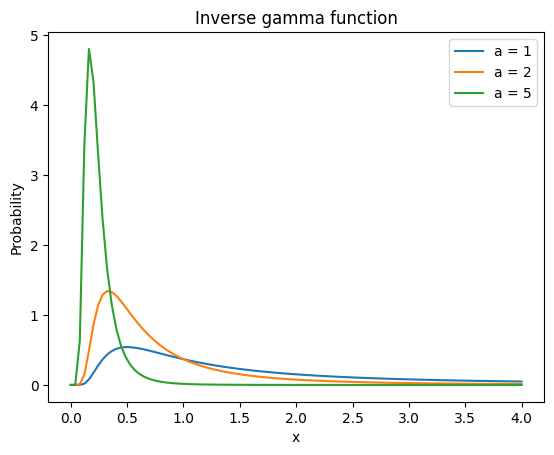

In [55]:
# Plot the inverse gamma distribution
x = np.linspace(0, 4, 100)
plt.plot(x, stats.invgamma.pdf(x, 1), label='a = 1')
plt.plot(x, stats.invgamma.pdf(x, 2), label='a = 2')
plt.plot(x, stats.invgamma.pdf(x, 5), label='a = 5')
plt.xlabel('x')
plt.ylabel('Probability')
plt.title('Inverse gamma function')
plt.legend()
plt.show()

In [56]:
x0_min, x0_max = 0, 1
x_0 = np.random.uniform(low=x0_min, high=x0_max)
n_samples = 100
phi = np.random.uniform(low=-1, high=1)
a = 5
sigma = stats.invgamma.rvs(a)

print(f"x_0 = {x_0}")
print(f"phi = {phi}")
print(f"sigma = {sigma}")

# Generate the AR(1) signal
x = autoregressive_process(n_samples, x_0, phi, sigma)

x_0 = 0.038593880824919435
phi = -0.7292325771353418
sigma = 0.24564510045984292


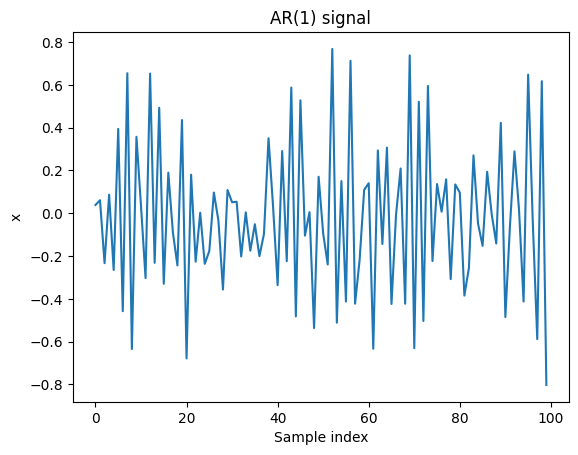

In [57]:
plt.plot(x)
plt.xlabel('Sample index')
plt.ylabel('x')
plt.title('AR(1) signal')
plt.show()

In [58]:
def joint(x, phi, sigma, x0_min, x0_max, a):
    """Calculate the joint probability p(x, phi, sigma)."""

    if phi < -1 or phi > 1:
        return 0
    
    if sigma < 0:
        return 0

    # Calculate the log probability
    p = np.log(1/(x0_max - x0_min)) + \
            np.log(stats.invgamma.pdf(sigma, a)) + \
            np.sum(np.log(stats.norm.pdf(x[1:], loc=phi * x[:-1], scale=sigma)))

    return np.exp(p)

In [59]:
phi_samples = [0]
sigma_samples = [0.5]

number_accepted = 0
proposal_sigma = 0.3
M = 10000

for i in range(1, M):
    phi_candidate = np.random.normal(phi_samples[-1], proposal_sigma)
    sigma_candidate = np.random.normal(sigma_samples[-1], proposal_sigma)

    q_prev = joint(x, phi_samples[-1], sigma_samples[-1], x0_min, x0_max, a)
    q_candidate = joint(x, phi_candidate, sigma_candidate, x0_min, x0_max, a)

    if q_candidate == 0 or np.random.uniform(0, 1) >= min(1, q_candidate/q_prev):
        phi_samples.append(phi_samples[-1])
        sigma_samples.append(sigma_samples[-1])
    else:
        # Accept the proposal
        phi_samples.append(phi_candidate)
        sigma_samples.append(sigma_candidate)
        number_accepted += 1

print(f"Percentage of samples accepted: {100 * number_accepted/M :0.2f}")

/tmp/ipykernel_4419/543870259.py:12: RuntimeWarning: divide by zero encountered in log
  np.log(stats.invgamma.pdf(sigma, a)) + \
/tmp/ipykernel_4419/543870259.py:13: RuntimeWarning: divide by zero encountered in log
  np.sum(np.log(stats.norm.pdf(x[1:], loc=phi * x[:-1], scale=sigma)))


Percentage of samples accepted: 2.82


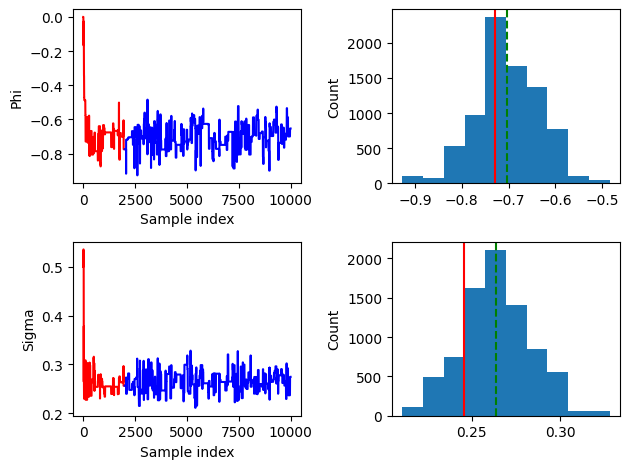

In [60]:
burnin = int(M/5)

def plot_samples_and_dist(subplot1, subplot2, samples, name, ground_truth):
    plt.subplot(subplot1)
    plt.plot(np.arange(burnin), samples[0:burnin], 'r')
    plt.plot(np.arange(burnin, M), samples[burnin:], 'b')
    plt.xlabel('Sample index')
    plt.ylabel(name)

    plt.subplot(subplot2)
    plt.hist(samples[burnin:])
    plt.axvline(x=ground_truth, color='r')
    plt.axvline(x=np.mean(samples[burnin:]), color='g', linestyle='--')
    plt.ylabel('Count')


plot_samples_and_dist(221, 222, phi_samples, 'Phi', phi)
plot_samples_and_dist(223, 224, sigma_samples, 'Sigma', sigma)

plt.tight_layout()
plt.show()

# Autocorrelated signal with a changepoint

In the section above the parameters of an AR(1) signal are inferred. Suppose instead that the signal has a changepoint where the AR(1) parameters change at time index $k$. The problem then becomes inferring the AR(1) parameters for the two regions and the unknown changepoint $k$.

For the first phase of the signal, the probability of the samples up to the changepoint $k$ is given by

$$
p(x | \phi_0, \sigma_0) = p(x_0) \prod_{i=1}^{k-1} p(x_i | x_{i-1}, \phi_0, \sigma_0)
$$

where $\phi_0$ is the autoregression coefficient and $\sigma_0$ is the standard deviation of the normally distributed noise.

In the second phase after the changepoint,

$$
p(x | \phi_1, \sigma_1) = p(x_k) \prod_{i=k+1}^{N-1} p(x_i | x_{i-1}, \phi_1, \sigma_1).
$$

The conditional probability of the $N$-samples $x$ is given by

$$
p(x | \sigma_0, \phi_0, \sigma_1, \phi_1, k) = p(x_0) \Big[ \prod_{i=1}^{k-1} p(x_i | x_{i-1}, \phi_0, \sigma_0) \Big] p(x_k) \Big[ \prod_{i=k+1}^{N-1} p(x_i | x_{i-1}, \phi_1, \sigma_1) \Big].
$$

The joint probability is given by

$$
p(x, \sigma_0, \phi_0, \sigma_1, \phi_1, k) = p(x | \sigma_0, \phi_0, \sigma_1, \phi_1, k) p(\sigma_0) p(\phi_0) p(\sigma_1) p(\phi_1) p(k)
$$

where $p(k)$ is the prior probability of the changepoint.

In [61]:
def generate_signal_with_changepoints(x_0, x_k, n_samples, k, phi_0, sigma_0, phi_1, sigma_1):
    
    assert n_samples > 1
    assert 1 <= k < n_samples - 1
    assert -1 <= phi_0 <= 1
    assert -1 <= phi_1 <= 1
    assert sigma_0 >= 0
    assert sigma_1 >= 0 

    x = np.zeros(n_samples)
    x[:k] = autoregressive_process(k, x_0, phi_0, sigma_0)
    x[k:] = autoregressive_process(n_samples - k, x_k, phi_1, sigma_1)

    return x

In [62]:
n_samples = 100

x0_min, x0_max = 0, 1
x_0 = np.random.uniform(low=x0_min, high=x0_max)
x_k = np.random.uniform(low=x0_min, high=x0_max)

k = np.random.randint(1, n_samples-1)

phi_0 = np.random.uniform(low=-1, high=1)
phi_1 = np.random.uniform(low=-1, high=1)

a = 5
sigma_0 = stats.invgamma.rvs(a)
sigma_1 = stats.invgamma.rvs(a)

x = generate_signal_with_changepoints(x_0, x_k, n_samples, k, phi_0, sigma_0, phi_1, sigma_1)

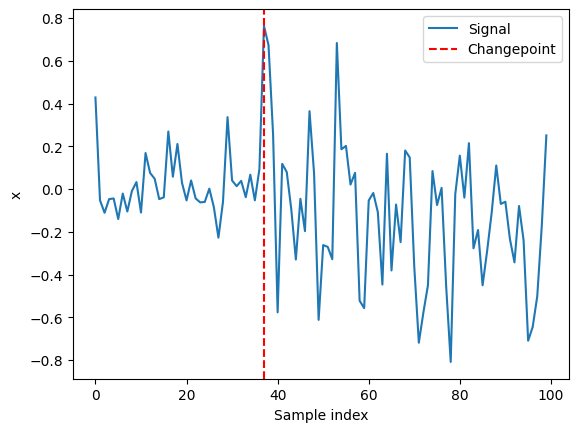

In [63]:
plt.plot(x, label='Signal')
plt.axvline(x=k, color='r', linestyle='--', label='Changepoint')
plt.xlabel('Sample index')
plt.ylabel('x')
plt.legend()
plt.show()

In [64]:
def joint_with_changepoint(x, phi_0, sigma_0, phi_1, sigma_1, k, x0_min, x0_max, a):
    """Calculate the joint probability with a single changepoint."""

    if phi_0 < -1 or phi_0 > 1 or phi_1 < -1 or phi_1 > 1:
        return 0
    
    if sigma_0 <= 0 or sigma_1 <= 0:
        return 0
    
    if k <= 0 or k > (len(x) - 1):
        return 0

    # Calculate the log probability (note that the 0th and kth elements are
    # omitted)
    p = 2*np.log(1/(x0_max - x0_min)) + \
        np.log(1/(len(x) - 2)) + \
        np.log(stats.invgamma.pdf(sigma_0, a)) + \
        np.log(stats.invgamma.pdf(sigma_1, a)) + \
        np.sum(np.log(stats.norm.pdf(x[1:k], loc=phi_0 * x[:(k-1)], scale=sigma_0))) + \
        np.sum(np.log(stats.norm.pdf(x[(k+1):], loc=phi_1 * x[k:-1], scale=sigma_1)))

    return np.exp(p)

In [65]:
phi_0_samples = [0]
sigma_0_samples = [1]
phi_1_samples = [0]
sigma_1_samples = [1]
k_samples = [int(len(x)/2)]

number_accepted = 0
proposal_sigma = 0.05
M = 20000

for i in range(1, M):
    phi_0_candidate = np.random.normal(phi_0_samples[-1], proposal_sigma)
    sigma_0_candidate = np.random.normal(sigma_0_samples[-1], proposal_sigma)
    
    phi_1_candidate = np.random.normal(phi_1_samples[-1], proposal_sigma)
    sigma_1_candidate = np.random.normal(sigma_1_samples[-1], proposal_sigma)

    k_candidate = int(np.random.normal(k_samples[-1], 3))

    q_prev = joint_with_changepoint(x, phi_0_samples[-1], sigma_0_samples[-1], 
                                    phi_1_samples[-1], sigma_1_samples[-1], 
                                    k_samples[-1], 
                                    x0_min, x0_max, a)

    q_candidate = joint_with_changepoint(x, phi_0_candidate, sigma_0_candidate, 
                                         phi_1_candidate, sigma_1_candidate, 
                                         k_candidate, 
                                         x0_min, x0_max, a)

    if q_candidate == 0 or np.random.uniform(0, 1) >= min(1, q_candidate/q_prev):
        phi_0_samples.append(phi_0_samples[-1])
        sigma_0_samples.append(sigma_0_samples[-1])
        phi_1_samples.append(phi_1_samples[-1])
        sigma_1_samples.append(sigma_1_samples[-1])     
        k_samples.append(k_samples[-1])
    else:
        # Accept the proposal
        phi_0_samples.append(phi_0_candidate)
        sigma_0_samples.append(sigma_0_candidate)
        phi_1_samples.append(phi_1_candidate)
        sigma_1_samples.append(sigma_1_candidate)     
        k_samples.append(k_candidate)   
        number_accepted += 1
        
print(f"Percentage of samples accepted: {100 * number_accepted/M :0.2f}")

/tmp/ipykernel_4419/4155120629.py:20: RuntimeWarning: divide by zero encountered in log
  np.sum(np.log(stats.norm.pdf(x[(k+1):], loc=phi_1 * x[k:-1], scale=sigma_1)))
/tmp/ipykernel_4419/4155120629.py:19: RuntimeWarning: divide by zero encountered in log
  np.sum(np.log(stats.norm.pdf(x[1:k], loc=phi_0 * x[:(k-1)], scale=sigma_0))) + \
/tmp/ipykernel_4419/4155120629.py:17: RuntimeWarning: divide by zero encountered in log
  np.log(stats.invgamma.pdf(sigma_0, a)) + \


Percentage of samples accepted: 5.78


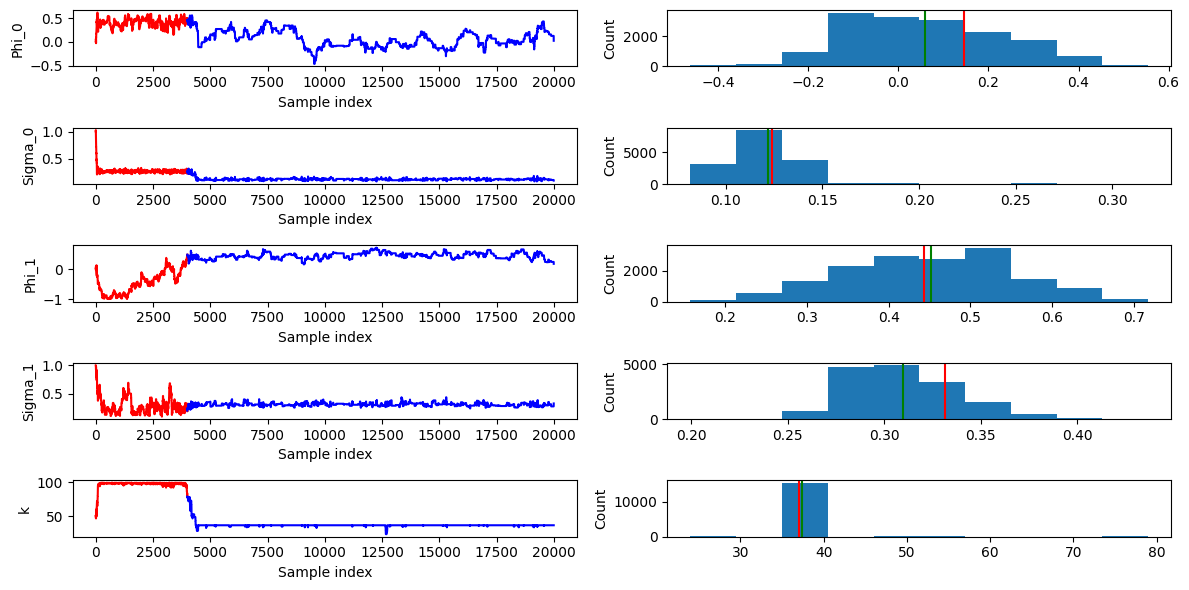

In [66]:
burnin = int(M/5)

def plot_samples_and_dist(axs, samples, name, ground_truth):

    axs[0].plot(np.arange(burnin), samples[0:burnin], 'r')
    axs[0].plot(np.arange(burnin, M), samples[burnin:], 'b')
    axs[0].set_xlabel('Sample index')
    axs[0].set_ylabel(name)

    axs[1].hist(samples[burnin:])
    axs[1].axvline(x=ground_truth, color='r')
    axs[1].axvline(x=np.mean(samples[burnin:]), color='g')
    axs[1].set_ylabel('Count')

fig = plt.figure(figsize=(12,6))
axs = fig.subplots(5, 2)

plot_samples_and_dist(axs[0], phi_0_samples, 'Phi_0', phi_0)
plot_samples_and_dist(axs[1], sigma_0_samples, 'Sigma_0', sigma_0)
plot_samples_and_dist(axs[2], phi_1_samples, 'Phi_1', phi_1)
plot_samples_and_dist(axs[3], sigma_1_samples, 'Sigma_1', sigma_1)
plot_samples_and_dist(axs[4], k_samples, 'k', k)

plt.tight_layout()
plt.show()